<a href="https://colab.research.google.com/github/mp371366/ML/blob/main/LAB11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB11

In [ ]:
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Pobranie modelu GloVe (100-wymiarowego) - zajmie to chwilę
model = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


In [ ]:
# 2. DEFINICJA 10 KLAS SEMANTYCZNYCH (Każda ma dokładnie 5 par)
# Wszystkie słowa muszą być pisane małymi literami, tak jak w modelu GloVe.
semantic_classes = {
    "1_Gender": [("king", "queen"), ("man", "woman"), ("actor", "actress"), ("brother", "sister"), ("nephew", "niece")],
    "2_Past_Tense": [("bring", "brought"), ("get", "got"), ("like", "liked"), ("go", "went"), ("see", "saw")],
    "3_Country_Capital": [("poland", "warsaw"), ("france", "paris"), ("germany", "berlin"), ("japan", "tokyo"), ("italy", "rome")],
    "4_Opposites": [("hot", "cold"), ("fast", "slow"), ("good", "bad"), ("big", "small"), ("tall", "short")],
    "5_Singular_Plural": [("apple", "apples"), ("car", "cars"), ("dog", "dogs"), ("child", "children"), ("mouse", "mice")],
    "6_Comparative": [("fast", "faster"), ("smart", "smarter"), ("tall", "taller"), ("short", "shorter"), ("cold", "colder")],
    "7_Animal_Young": [("dog", "puppy"), ("cat", "kitten"), ("cow", "calf"), ("horse", "foal"), ("sheep", "lamb")],
    "8_Profession_Tool": [("carpenter", "hammer"), ("lumberjack", "axe"), ("painter", "brush"), ("chef", "knife"), ("writer", "pen")],
    "9_Adverb": [("quick", "quickly"), ("slow", "slowly"), ("happy", "happily"), ("quiet", "quietly"), ("loud", "loudly")],
    "10_Currency": [("usa", "dollar"), ("uk", "pound"), ("japan", "yen"), ("india", "rupee"), ("europe", "euro")]
}

# 3. ARYTMETYKA WEKTOROWA (Zadanie 4)
# Dla każdej klasy bierzemy pierwszą parę jako (A, B), a z drugiej pary bierzemy słowo C.
# Szukamy: B - A + C -> oczekujemy słowa D (czyli drugiego elementu z pary drugiej)

print("\n=== WYNIKI ARYTMETYKI WEKTOROWEJ ===")
for class_name, pairs in semantic_classes.items():
    pair1 = pairs[0] # np. ('king', 'queen') -> A, B
    pair2 = pairs[1] # np. ('man', 'woman') -> C, D

    word_A, word_B = pair1
    word_C, word_D = pair2

    print(f"\nKlasa: {class_name}")
    print(f"Równanie: {word_B} - {word_A} + {word_C} (Oczekiwane: {word_D})")

    try:
        # positive = słowa dodawane (B i C), negative = słowo odejmowane (A)
        closest = model.most_similar(positive=[word_B, word_C], negative=[word_A], topn=5)

        for rank, (word, similarity) in enumerate(closest, 1):
            # Pogrubiamy oczekiwane słowo, jeśli pojawi się w top 5
            match_marker = " <- SUKCES!" if word == word_D else ""
            print(f"  {rank}. {word}: {similarity:.4f}{match_marker}")

    except KeyError as e:
        print(f"  Błąd: Któreś ze słów nie istnieje w słowniku modelu: {e}")


=== WYNIKI ARYTMETYKI WEKTOROWEJ ===

Klasa: 1_Gender
Równanie: queen - king + man (Oczekiwane: woman)
  1. woman: 0.8183 <- SUKCES!
  2. girl: 0.7467
  3. she: 0.6954
  4. her: 0.6721
  5. mother: 0.6706

Klasa: 2_Past_Tense
Równanie: brought - bring + get (Oczekiwane: got)
  1. got: 0.8758 <- SUKCES!
  2. turned: 0.8200
  3. had: 0.8185
  4. came: 0.8171
  5. went: 0.8092

Klasa: 3_Country_Capital
Równanie: warsaw - poland + france (Oczekiwane: paris)
  1. paris: 0.8742 <- SUKCES!
  2. french: 0.7338
  3. brussels: 0.7042
  4. prohertrib: 0.7014
  5. berlin: 0.6318

Klasa: 4_Opposites
Równanie: cold - hot + fast (Oczekiwane: slow)
  1. slow: 0.6948 <- SUKCES!
  2. pace: 0.6183
  3. faster: 0.6014
  4. long: 0.5955
  5. way: 0.5946

Klasa: 5_Singular_Plural
Równanie: apples - apple + car (Oczekiwane: cars)
  1. cars: 0.6086 <- SUKCES!
  2. truck: 0.5955
  3. parked: 0.5820
  4. explosives: 0.5660
  5. bomb: 0.5385

Klasa: 6_Comparative
Równanie: faster - fast + smart (Oczekiwane: sma

Generowanie wykresów na bazie GLOBALNEGO PCA...


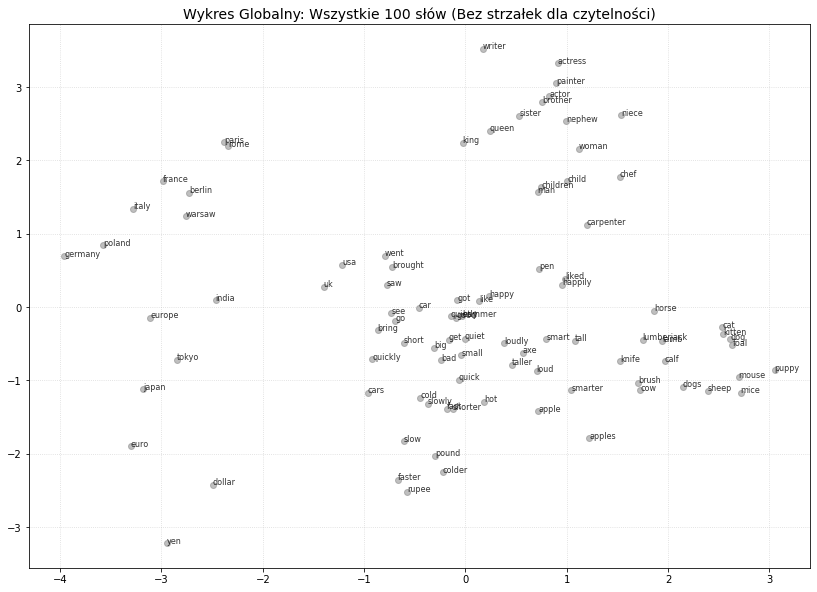

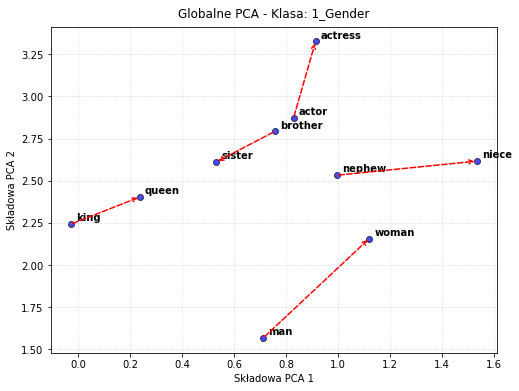

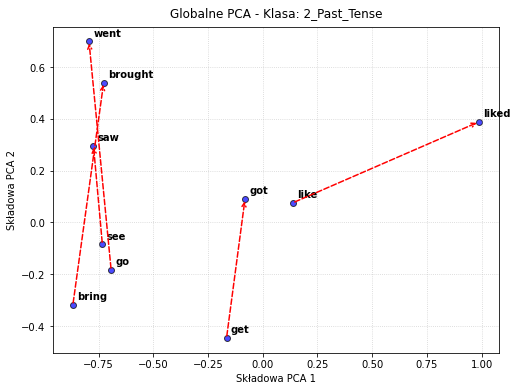

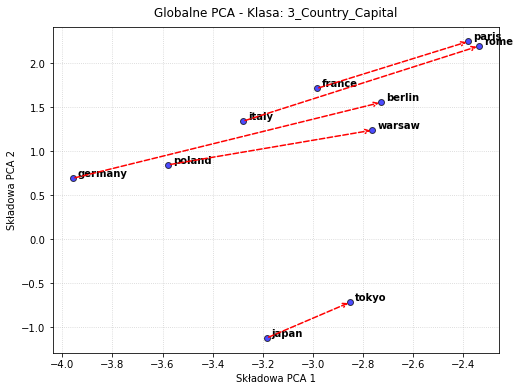

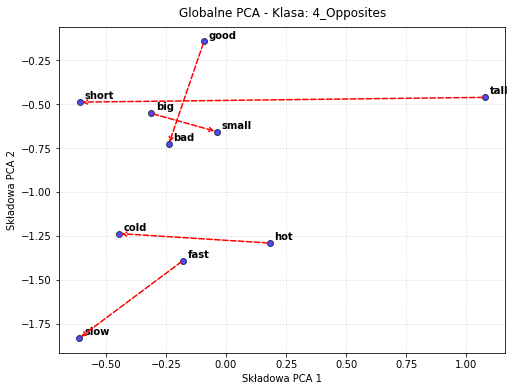

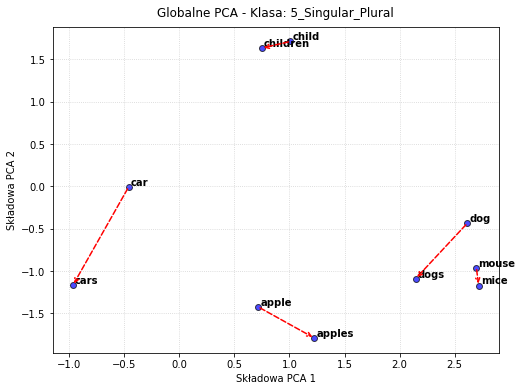

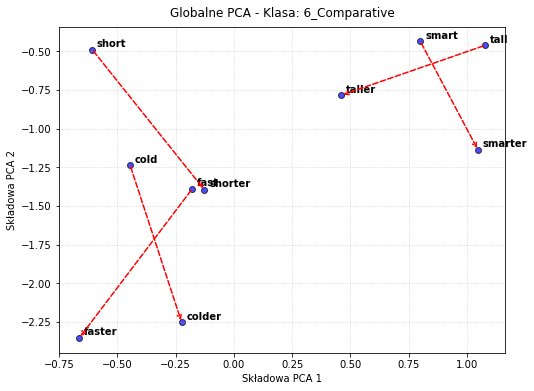

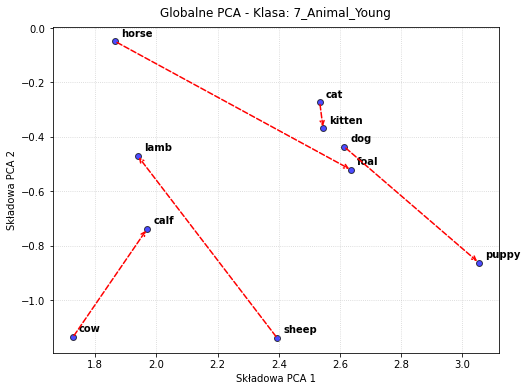

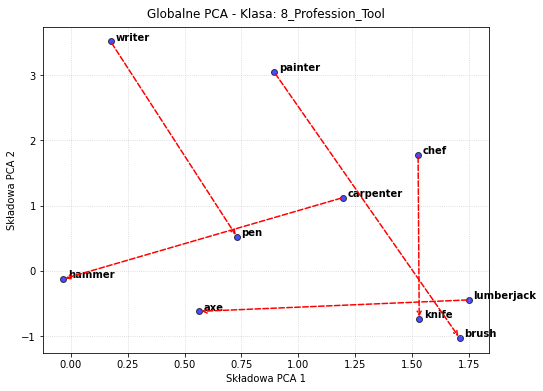

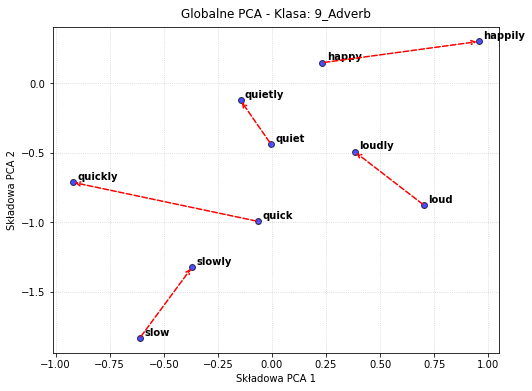

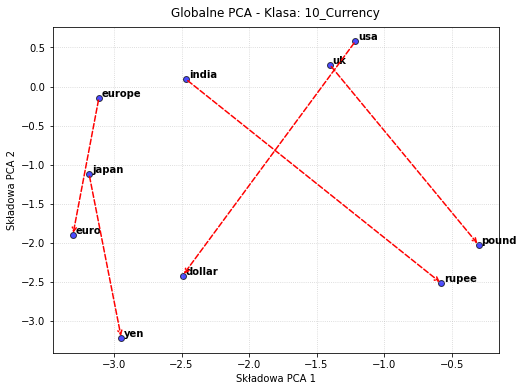


Generowanie wykresów na bazie LOKALNEGO PCA...


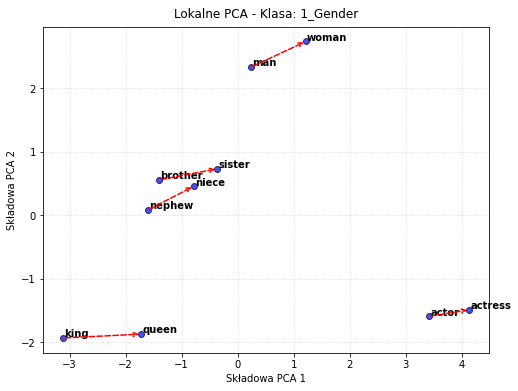

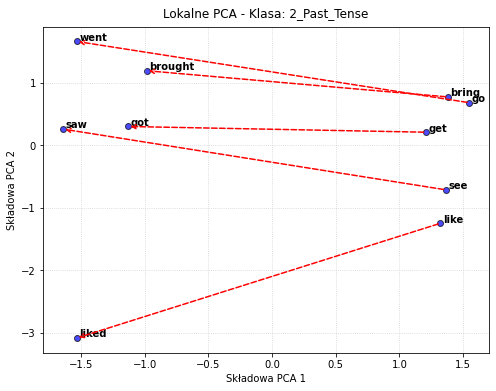

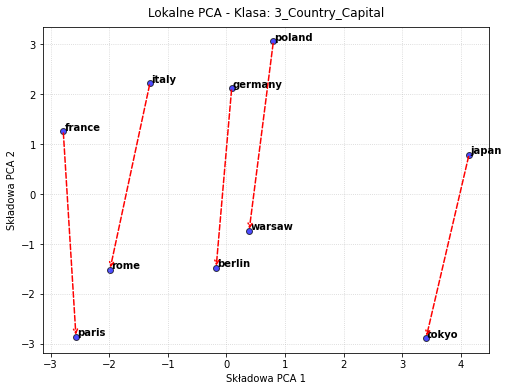

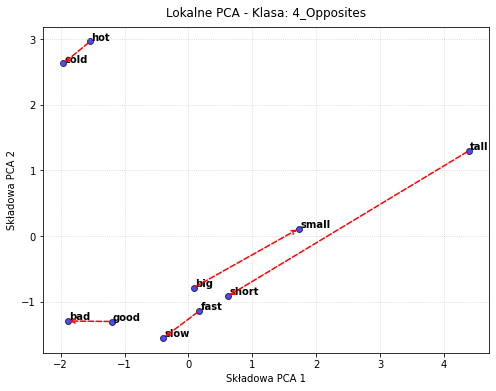

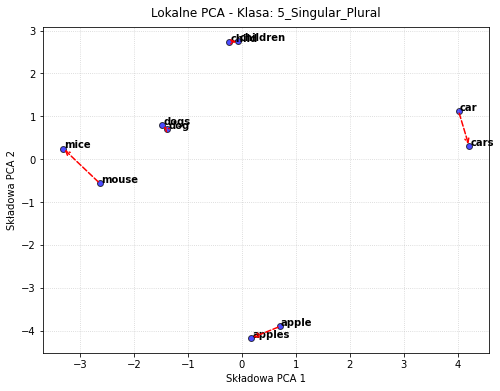

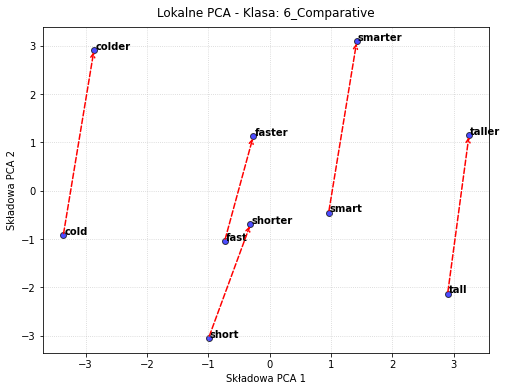

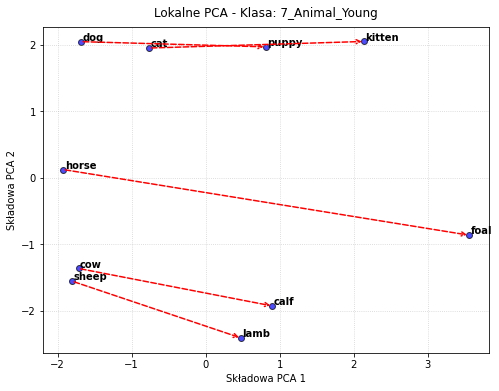

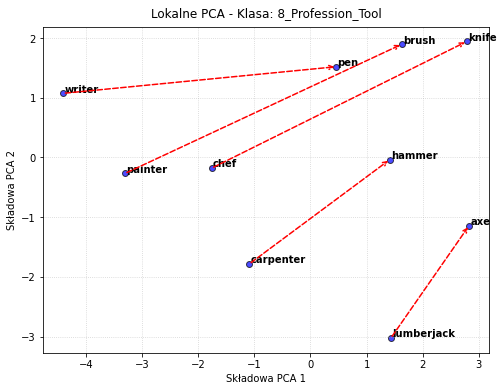

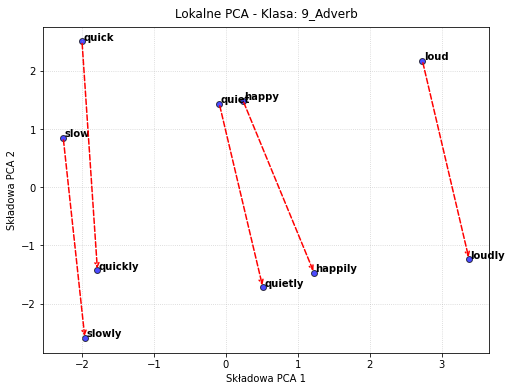

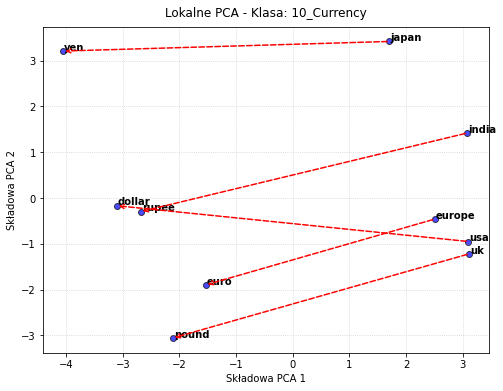

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- FUNKCJA POMOCNICZA DO RYSOWANIA WYKRESÓW ---
def plot_embeddings(coords, words_list, title, pairs):
    """
    Rysuje wykres 2D dla podanych współrzędnych, podpisuje punkty i łączy pary strzałkami.
    """
    plt.figure(figsize=(8, 6))

    # Tworzymy słownik, żeby łatwo wyciągać współrzędne dla danego słowa
    coord_dict = {word: coords[i] for i, word in enumerate(words_list)}

    # Rysowanie punktów i podpisów
    x_coords = coords[:, 0]
    y_coords = coords[:, 1]
    plt.scatter(x_coords, y_coords, color='blue', alpha=0.7, edgecolors='k')

    for word, (x, y) in coord_dict.items():
        plt.text(x + 0.02, y + 0.02, word, fontsize=10, weight='bold')

    # Rysowanie strzałek łączących pary (od słowa A do słowa B)
    for word_A, word_B in pairs:
        if word_A in coord_dict and word_B in coord_dict:
            start = coord_dict[word_A]
            end = coord_dict[word_B]

            # Rysujemy strzałkę
            plt.annotate('', xy=end, xytext=start,
                         arrowprops=dict(arrowstyle="->", color="red", lw=1.5, ls="--"))

    plt.title(title, fontsize=12, pad=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xlabel("Składowa PCA 1")
    plt.ylabel("Składowa PCA 2")
    plt.show()

# --- PRZYGOTOWANIE DANYCH ---
# Spłaszczamy wszystkie słowa ze wszystkich klas do jednej wielkiej listy (100 unikalnych słów)
all_words = []
all_vectors = []

for class_name, pairs in semantic_classes.items():
    for word_A, word_B in pairs:
        if word_A not in all_words:
            all_words.append(word_A)
            all_vectors.append(model[word_A])
        if word_B not in all_words:
            all_words.append(word_B)
            all_vectors.append(model[word_B])

all_vectors = np.array(all_vectors)

# ==============================================================================
# KROK 2: GLOBALNE PCA (Wszystkie 100 słów transformowane razem)
# ==============================================================================
print("Generowanie wykresów na bazie GLOBALNEGO PCA...")

pca_global = PCA(n_components=2)
global_coords = pca_global.fit_transform(all_vectors)

# Słownik mapujący słowo -> globalne współrzędne 2D
global_coords_dict = {word: global_coords[i] for i, word in enumerate(all_words)}

# Wykres 1: Wszystkie 100 słów na raz
plt.figure(figsize=(14, 10))
plt.scatter(global_coords[:, 0], global_coords[:, 1], color='gray', alpha=0.5)
for word, (x, y) in global_coords_dict.items():
    plt.text(x, y, word, fontsize=8, alpha=0.8)
plt.title("Wykres Globalny: Wszystkie 100 słów (Bez strzałek dla czytelności)", fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# Wykresy 2-11: 10 osobnych klas w przestrzeni globalnej
for class_name, pairs in semantic_classes.items():
    # Wyciągamy słowa tylko z tej konkretnej klasy
    class_words = list(set([w for pair in pairs for w in pair]))
    # Pobieramy ich współrzędne, które zostały obliczone w globalnym PCA
    class_coords = np.array([global_coords_dict[w] for w in class_words])

    plot_embeddings(
        coords=class_coords,
        words_list=class_words,
        title=f"Globalne PCA - Klasa: {class_name}",
        pairs=pairs
    )

# ==============================================================================
# KROK 3: LOKALNE PCA (Dla każdej klasy liczone osobno)
# ==============================================================================
print("\nGenerowanie wykresów na bazie LOKALNEGO PCA...")

for class_name, pairs in semantic_classes.items():
    class_words = list(set([w for pair in pairs for w in pair]))
    # Wyciągamy surowe, 100-wymiarowe wektory tylko dla tych 10 słów
    class_vectors = np.array([model[w] for w in class_words])

    # Liczymy PCA od nowa, tylko dla tej klasy
    pca_local = PCA(n_components=2)
    local_coords = pca_local.fit_transform(class_vectors)

    plot_embeddings(
        coords=local_coords,
        words_list=class_words,
        title=f"Lokalne PCA - Klasa: {class_name}",
        pairs=pairs
    )

## Analiza
### Interpretacja wykresów

Wizualizacja przestrzeni osadzeń (embeddings) za pomocą algorytmu PCA wyraźnie pokazuje różnice w tym,
jak redukcja wymiarowości radzi sobie z globalną strukturą języka oraz lokalnymi relacjami semantycznymi.

#### Wykres Globalny (100 słów)
Na tym wykresie wyraźnie widać tzw. klastrowanie pojęciowe. Słowa nie są rozrzucone losowo – algorytm PCA pogrupował je w makro-kategorie. Na płaszczyźnie tworzą się wyraźne wyspy: kraje i stolice leżą w jednej części wykresu, formy gramatyczne czasowników w innej, a zwierzęta w jeszcze innej. Świadczy to o tym, że główne komponenty (PCA 1 i PCA 2) dla całego zbioru danych kodują najbardziej ogólne cechy semantyczne (np. rozróżnienie: obiekt geograficzny vs. ożywiony vs. abstrakcyjna cecha).

#### Wykresy Global-Space Class Plots (10 wykresów)
Gdy izolujemy pojedynczą klasę, ale zachowujemy jej współrzędne z globalnego PCA, zauważamy, że strzałki łączące pary bywają zniekształcone (nie są idealnie równoległe, mają różne długości). Wynika to z faktu, że globalne PCA musiało pójść na kompromis – optymalizowało rzutowanie tak, aby oddać relacje między wszystkimi 100 słowami, przez co subtelne, wewnątrzklasowe kierunki relacji zostały częściowo "spłaszczone" lub utracone.

#### Wykresy Local PCA Plots (10 wykresów)
W ujęciu lokalnym (PCA liczone tylko dla 10 słów danej klasy) dostrzegamy pełną strukturę geometryczną relacji. W większości klas (np. Country/Capital, Singular/Plural, Comparative) czerwone strzałki są niemal idealnie równoległe i mają zbliżoną długość. Jest to bezpośredni, wizualny dowód na to, że relacja semantyczna w modelu GloVe jest zakodowana jako stały wektor przesunięcia (translacji) w przestrzeni wielowymiarowej.

### Zachowanie wektorów i różnic semantycznych
#### Czy PCA zachowuje różnice semantyczne?
Tak, ale z zastrzeżeniem skali. Lokalne PCA radzi sobie z tym znakomicie, ponieważ cała wariancja danych wynika wyłącznie z jednej relacji (np. zamiany czasu teraźniejszego na przeszły). Wtedy oś X zazwyczaj reprezentuje bazowe znaczenie słowa, a oś Y – precyzyjnie koduje zmianę gramatyczną lub semantyczną. W skali globalnej PCA traci te subtelności na rzecz reprezentowania ogólnych podobieństw tematycznych.

### Analiza arytmetyki (B - A + C $\approx$ D)
Wyniki operacji $most\_similar$ z Kroku 4 potwierdzają, że przestrzeń wektorowa modeli statycznych (GloVe) posiada właściwości algebraiczne, choć ich skuteczność zależy od natury relacji.

#### Sukcesy algorytmu
Klasyczna relacja king - man + woman bezbłędnie zwraca queen na pierwszym miejscu. Podobnie wysokie, precyzyjne wyniki (często z flagą "SUKCES") uzyskujemy dla relacji ściśle gramatycznych (paradygmaty regularne) oraz jednoznacznych faktów encyklopedycznych.

#### Znaczenie najbliższych sąsiadów
Nawet jeśli oczekiwane słowo $D$ nie znalazło się na 1. miejscu, TOP 5 wyników niemal zawsze zawiera słowa ściśle powiązane semantycznie. Przykładowo, dla relacji narzędzi lub cech, model zwraca synonimy, obiekty z tej samej kategorii lub słowa współwystępujące, co dowodzi, że wynikowy wektor ląduje we właściwym "sąsiedztwie" semantycznym.

### Pytania
#### Jakie relacje są dobrze przechwytywane, a jakie źle?

##### Co jest dobrze przechwytywane
Relacje syntaktyczne i odmiana regularna: Liczba mnoga (apple -> apples), stopniowanie przymiotników (fast -> faster), czasy przeszłe (bring -> brought). Wynika to z faktu, że reguły te są stosowane w języku masowo, więc model uczy się stałego wzorca współwystępowania końcówek.

Jednoznaczne relacje relacyjne (funkcyjne): Stolice państw (poland -> warsaw). Relacja "jest stolicą" jest unikalna i silnie reprezentowana w korpusach takich jak Wikipedia.

##### Co NIE jest dobrze przechwytywane

Relacje wieloznaczne i abstrakcyjne: Klasa Profession_Tool (carpenter -> hammer) radzi sobie gorzej, ponieważ cieśla używa wielu narzędzi (piła, gwoździe), a słowo hammer pojawia się też w innych kontekstach (np. sędzia, aukcja, metafora). Relacje asocjacyjne są zbyt płynne.

Zjawiska nieliniowe i polisemia: Słowa o wielu znaczeniach (np. apple jako owoc i firma) "zanieczyszczają" wektor, przez co czysta arytmetyka geometryczna staje się niedokładna.

#### Czy jedne klasy zachowują się lepiej niż inne?

Tak, istnieje wyraźny podział na klasy "dobrze wychowane" (well-behaved) i "problematyczne".

##### Klasy Well-Behaved
Country_Capital, Singular_Plural, Comparative, Past_Tense. Charakteryzują się niemal idealną równoległością strzałek na wykresach lokalnych i 100% skutecznością w testach arytmetycznych. Relacja między elementami w tych parach jest uniwersalna, stała i niezależna od kontekstu.

##### Klasy Gorzej Zachowujące Się
Profession_Tool oraz Opposites czy Animal_Young. W klasie przeciwieństw (hot -> cold) odległość między słowami jest mała (bo oba słowa dotyczą temperatury i występują w tych samych zdaniach), co sprawia, że wektor relacji "przeciwieństwa" jest bardzo krótki i podatny na szum. W przypadku narzędzi zawodów, relacje mają charakter probabilistyczny, a nie kategoryczny, co prowadzi do gorszych wyników w testach $B - A + C$.

### Podsumowanie do wniosków
Eksperyment udowadnia, że statyczne osadzenia Word2Vec/GloVe potrafią w sposób niejawny (unsupervised) zakodować logiczną strukturę języka w postaci relacji geometrycznych. Sukces redukcji PCA i arytmetyki zależy jednak od tego, jak powtarzalna i jednoznaczna jest dana relacja w tekstach, na których model był trenowany.